### **For this assignment the only permitted libraries to use are Numpy, Scipy, MatplotLib and Pandas! All four have been imported for you in this Notebook.**

In [35]:
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data loading

Train and Test sets can be found in the `Resources` folder. You can choose to visualize your data all at once, in windows, or only considering a subset of sensors to detect which ones would prove most useful to your analysis.
An example of such a visualization can be found in the following cell.

In [36]:
train_file_path = 'lab1_train.csv'

train_data = pd.read_csv(train_file_path, delimiter=',')

# Convert Timestamp column to datetime
train_data['Timestamp'] = pd.to_datetime(train_data['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')

test_file_path = 'lab1_test.csv'

test_data = pd.read_csv(test_file_path, delimiter=',')

# Convert Timestamp column to datetime
test_data['Timestamp'] = pd.to_datetime(test_data['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')


C:\Users\Hristian Semerdzhiev\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


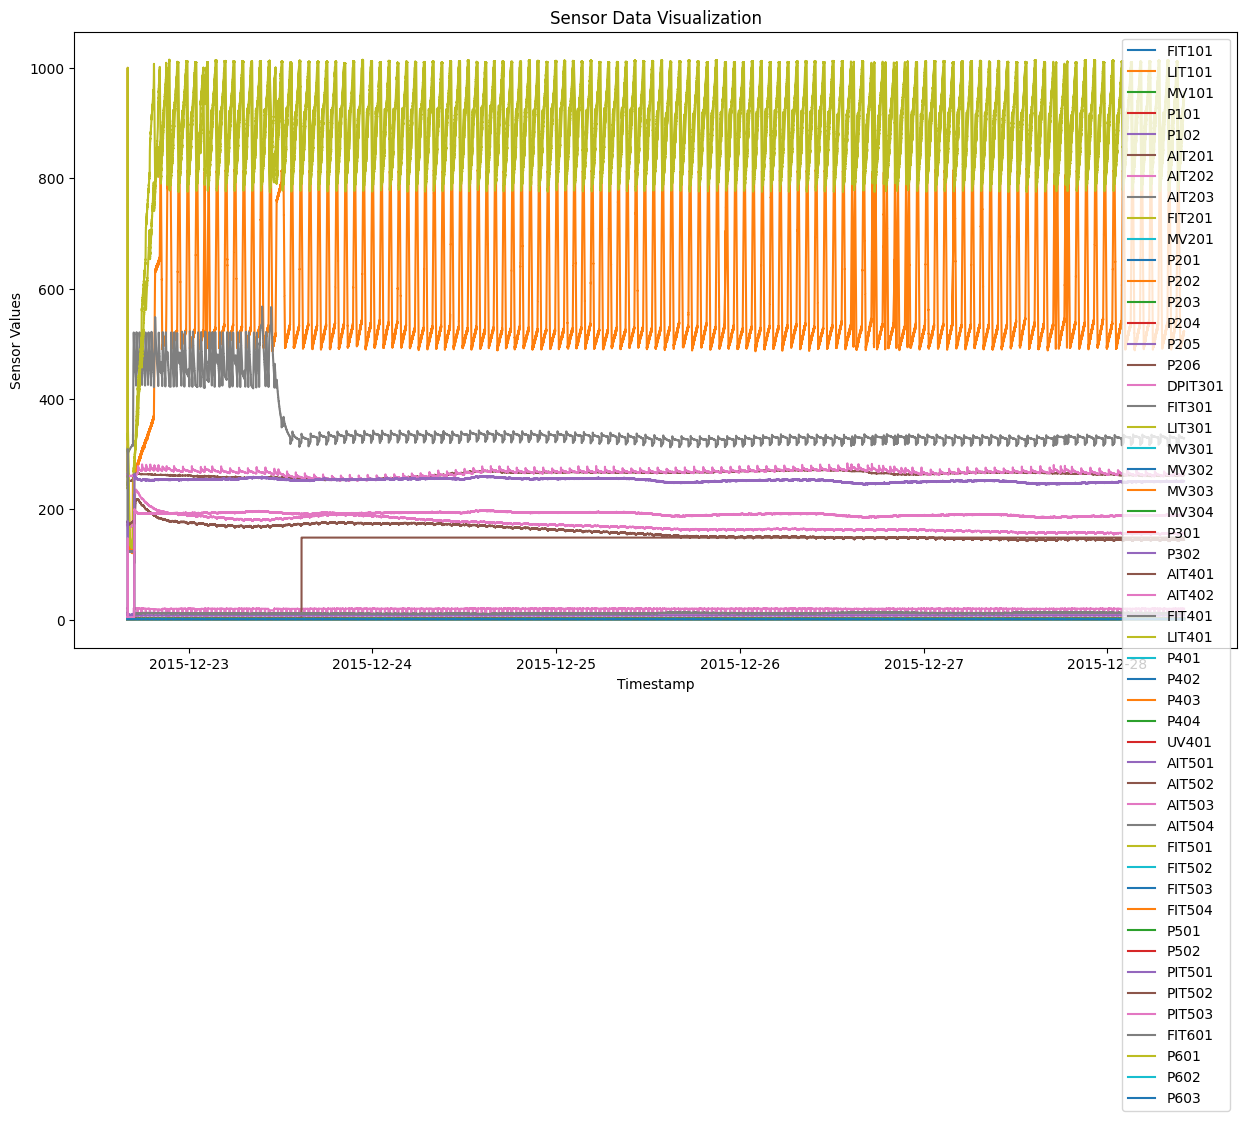

In [37]:
def visualize_sensor_data(df, window=None, sensors=None, title=None):
    # If title is None, use a default title
    if title is None:
        title = 'Sensor Data Visualization'

    # If window is None, visualize the entire dataset
    if window is None:
        start_index, end_index = 0, len(df)
    else:
        start_index, end_index = window

    # If sensors is None, select all sensor columns
    if sensors is None:
        sensors = df.columns[1:-1]

    # Plot each sensor in a different color
    plt.figure(figsize=(15, 8))
    for sensor in sensors:
        plt.plot(df['Timestamp'][start_index:end_index], df[sensor][start_index:end_index], label=sensor)

    plt.xlabel('Timestamp')
    plt.ylabel('Sensor Values')
    plt.title(title)
    plt.legend()

    plt.show()

visualize_sensor_data(train_data)

### Familiarization
    1. What types of signals are there?

We have 51 signals and 2 extra columns with the Timestamps of the data points and with the classification as Normal or Attack (anomaly). We have 496800 data points per signal (train set). Based on the type of the signal (signal concrete characteristics) there are digital signals (like a LIT101), discrete signals (like AIT401), periodic signals (like LIT101) and others.

(496800, 53)


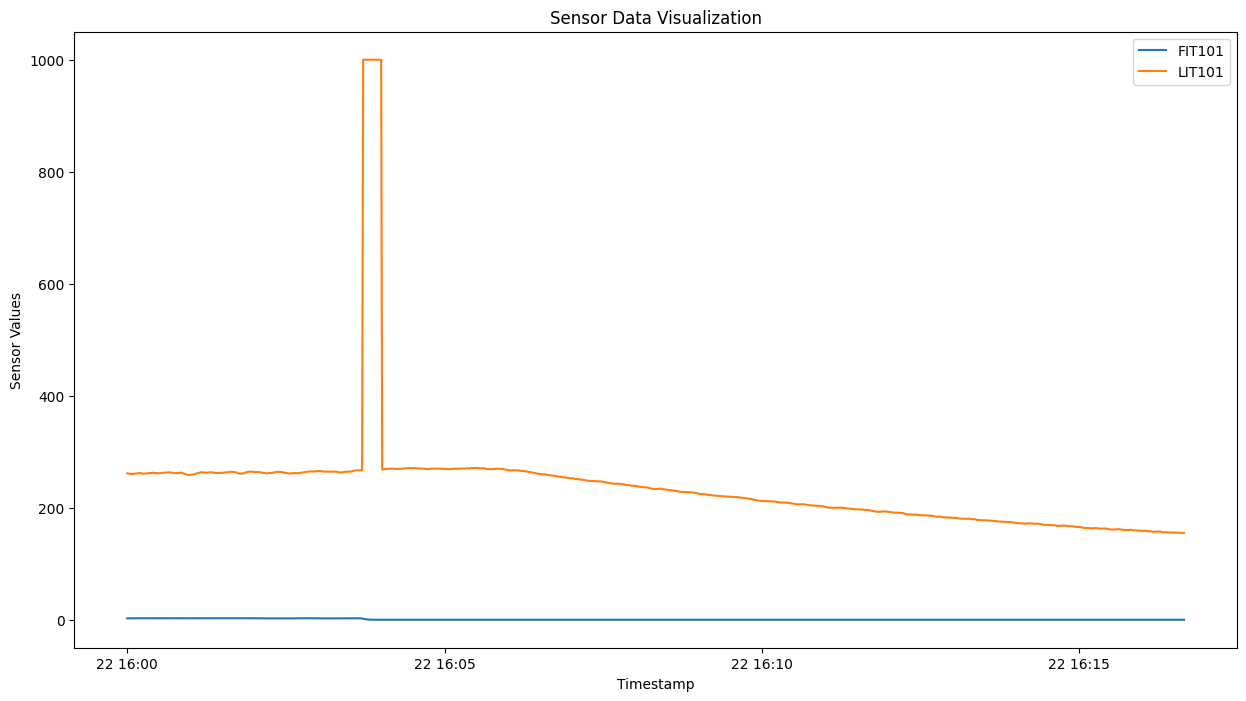

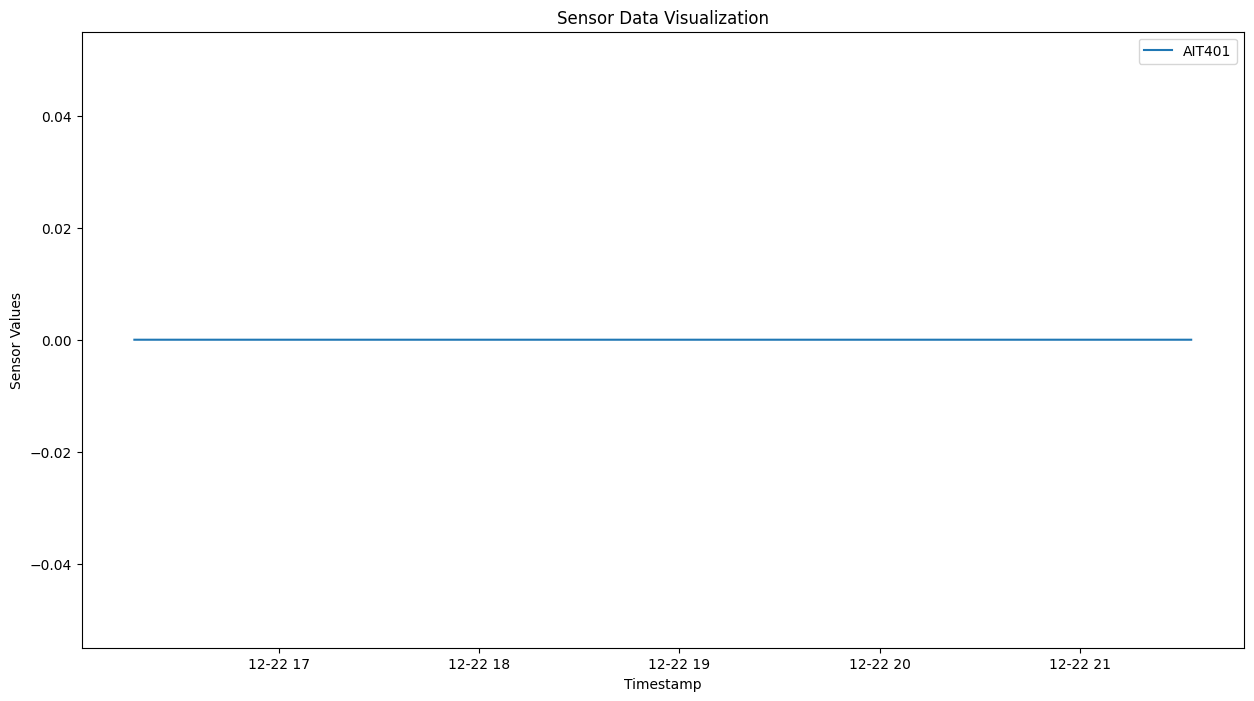

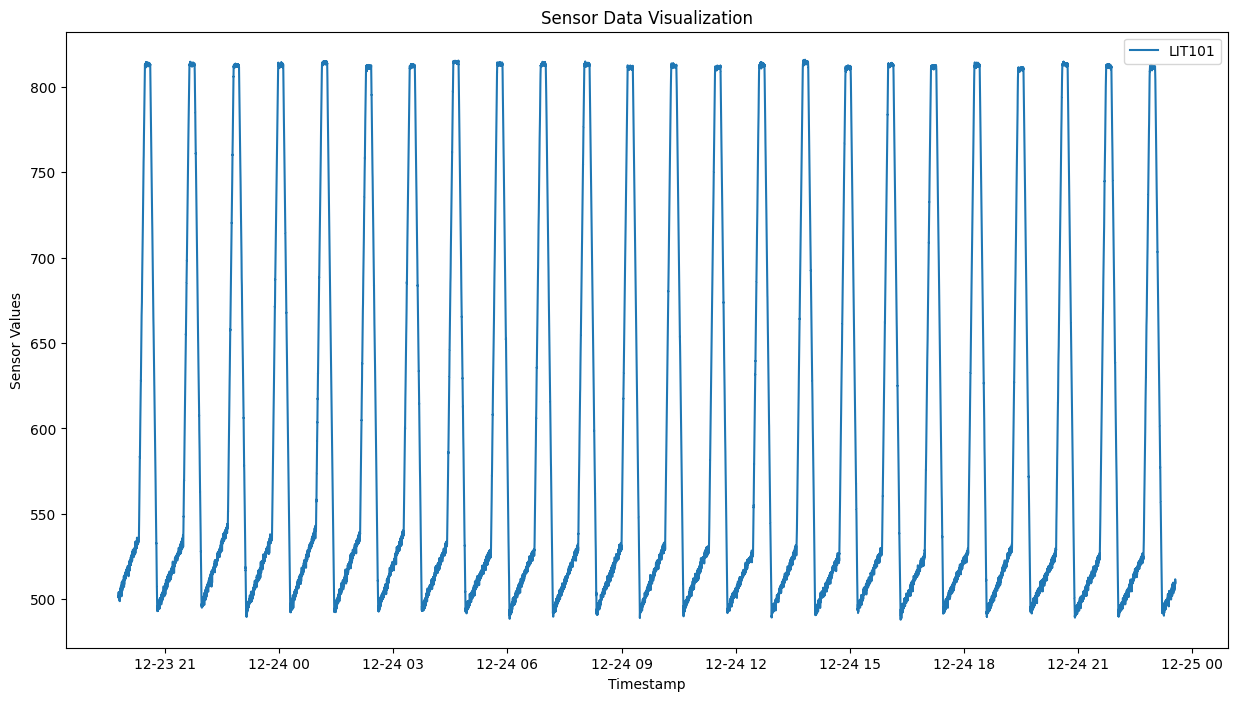

In [38]:
print(train_data.shape)
visualize_sensor_data(train_data, window=(0, 1000), sensors=['FIT101', 'LIT101'])
visualize_sensor_data(train_data, window=(1000, 20000), sensors=['AIT401'])
visualize_sensor_data(train_data, window=(100000, 200000), sensors=['LIT101'])

We can also divide them as numerical and categorical features.

In [39]:
# Numerical and categorical features
numerical_features = []
categorical_features = []

for column in train_data.columns:
    unique_values = train_data[column].nunique()
    if (column == 'Timestamp' or column == 'Normal/Attack'):
        continue
    if unique_values > 10:
        numerical_features.append(column)
    else:
        categorical_features.append(column)
     

In [40]:
print(f"Numerical features: {numerical_features}")

Numerical features: ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'PIT501', 'PIT502', 'PIT503', 'FIT601']


In [41]:
print(f"Categorical features: {categorical_features}")

Categorical features: ['MV101', 'P101', 'P102', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'P401', 'P402', 'P403', 'P404', 'UV401', 'P501', 'P502', 'P601', 'P602', 'P603']


    2. Are the signals correlated? Do they show cyclic behavior?

From the heatmap in train_corr_plot we see that there both positively (such as FIT501, FIT503) and negatively (such as AIT504, FIT501) correlated signals, as well as uncorrelated signals (such as P201, P601). Cyclic behaviour is shown from some signals. These that are periodic have cyclic behaviour (LIT101), while signals like AIT401 are acyclic (aperiodic).

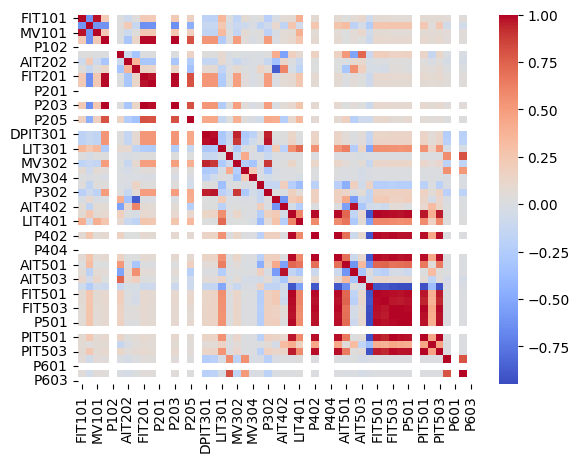

In [42]:
train_df = train_data.drop(columns=['Timestamp', 'Normal/Attack'])
correlation_df = train_df.corr()

# Now we plot the correlation matrix.
sns.heatmap(correlation_df, annot=False, cmap='coolwarm')
plt.show()

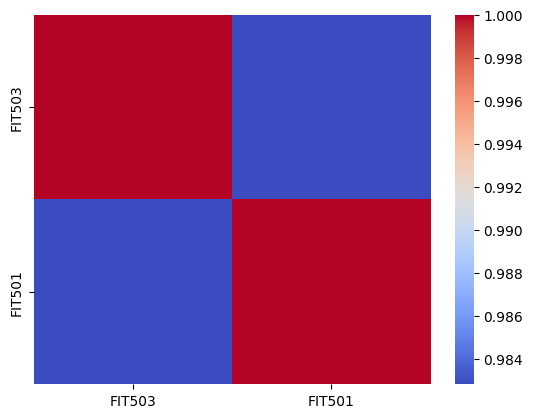

In [43]:
positive_correlation = train_data[['FIT503', 'FIT501']].corr()
# Now we plot the correlation matrix.
sns.heatmap(positive_correlation, annot=False, cmap='coolwarm')
plt.show()

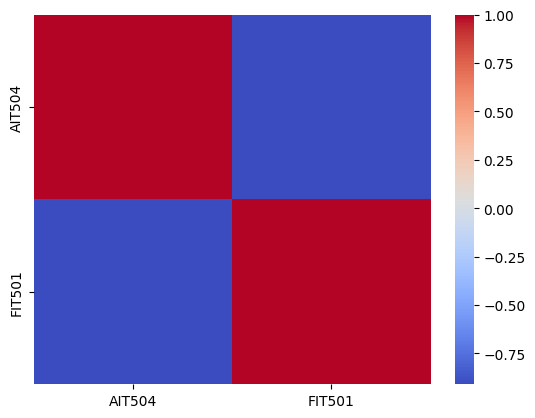

In [44]:
negative_correlation = train_data[['AIT504', 'FIT501']].corr()
# Now we plot the correlation matrix.
sns.heatmap(negative_correlation, annot=False, cmap='coolwarm')
plt.show()

C:\Users\Hristian Semerdzhiev\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\Hristian Semerdzhiev\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


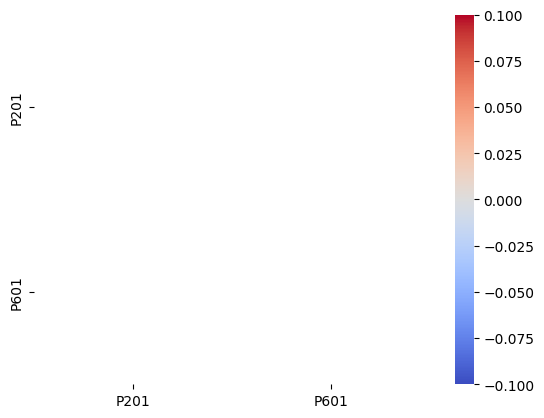

In [45]:
no_correlation = train_data[['P201', 'P601']].corr()
# Now we plot the correlation matrix.
sns.heatmap(no_correlation, annot=False, cmap='coolwarm')
plt.show()

### Dynamic Time Warping Based Anomaly Detection
We will use Dynamic Time Warping (DTW) to find anomalies in a given signal (we opted for 'LIT101'). In general, we go through the following steps. We create sliding windows with a specific size and stride over the train data (we explain more about it later in the notebook). We also create representative sliding windows that show 'normal behaviour' of the signal. The windows inside the two sets of sliding windows have the same size and stride, so that they can be easily compared by the DTW algorithm. We find a threshold value from the calculated residuals between the windows of the training data and the closest representative window. This threshold determines what we consider an anomaly. We, then, create sliding windows over the test data and compare these windows against the representative windows. We use the already calculated threshold to find the anomalies in the test data. We go more in-depth of the steps as they are presented in the notebook. 

In [46]:
def dynamic_time_warping(a, b):
    n = a.size
    m = b.size
    
    # Create a cost table (cumulative distance table)
    table = np.full((n, m), np.inf)

    # Initialize the first cell
    for i in range(n):
        for j in range(m):
            cost = distance(a[i], b[j])

            if i == 0 and j == 0:
                table[i, j] = cost
            elif i == 0:
                table[i, j] = cost + table[i, j - 1]
            elif j == 0:
                table[i, j] = cost + table[i - 1, j]
            else:
                table[i, j] = cost + min(
                    table[i - 1, j],   
                    table[i, j - 1],    
                    table[i - 1, j - 1] 
                )

    # DTW distance is in the bottom-right corner of the table
    dtw_distance = np.sqrt(table[-1, -1])

    return dtw_distance

#Distance helper function
def distance(a, b):
    value = (a-b)**2

    return value



Now, we are going to use the data of sensor LIT101 and create sliding windows across the data. We chose a window with size=10 and stride=300 as it provides decent runtime and detects plenty of anomalies. This is because with increasing window size, the runtime is also increasing and it takes too much time to compute (our DTW algorithm is O(n^2)). Moreover, with decreasing stride, the number of windows is increasing, so more checks need to be done by DTW. 
    
We see from the visualization that in the beginning of the sensor data, there are unstable values collected by the sensor. We remove these initial values from the data (outliers), since these points will create high residuals and so the threshold for finding anomalies will greatly increase and not find possible anomalies later in the data. We visualize the whole sensor data and then the subset of the data that we will use. Also, we visualize the data that we consider 'normal behaviour' and that we are going to use to create representative windows.

(496800,)


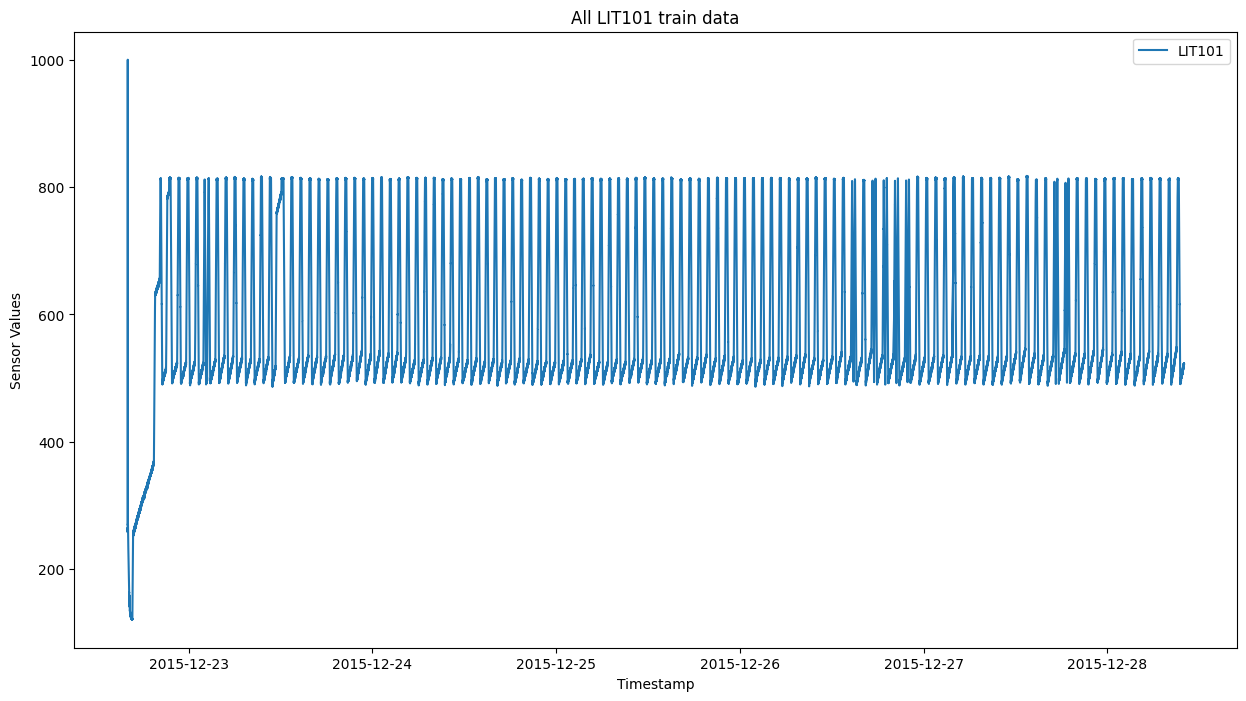

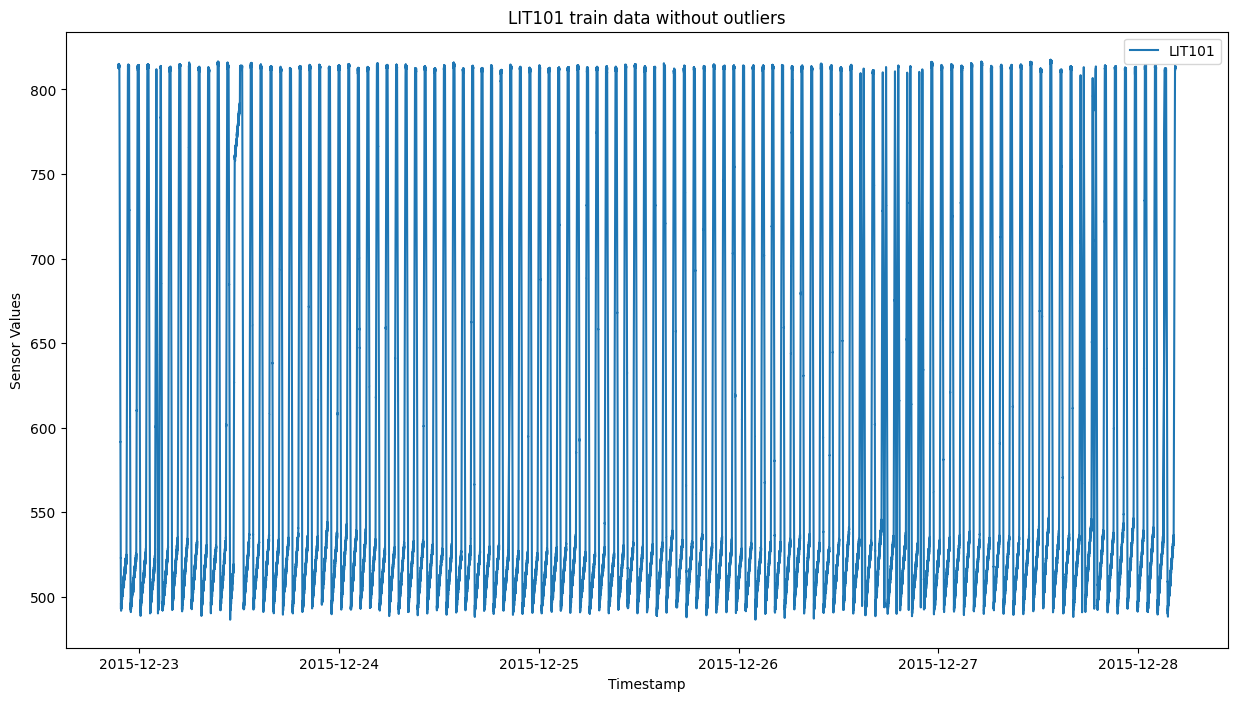

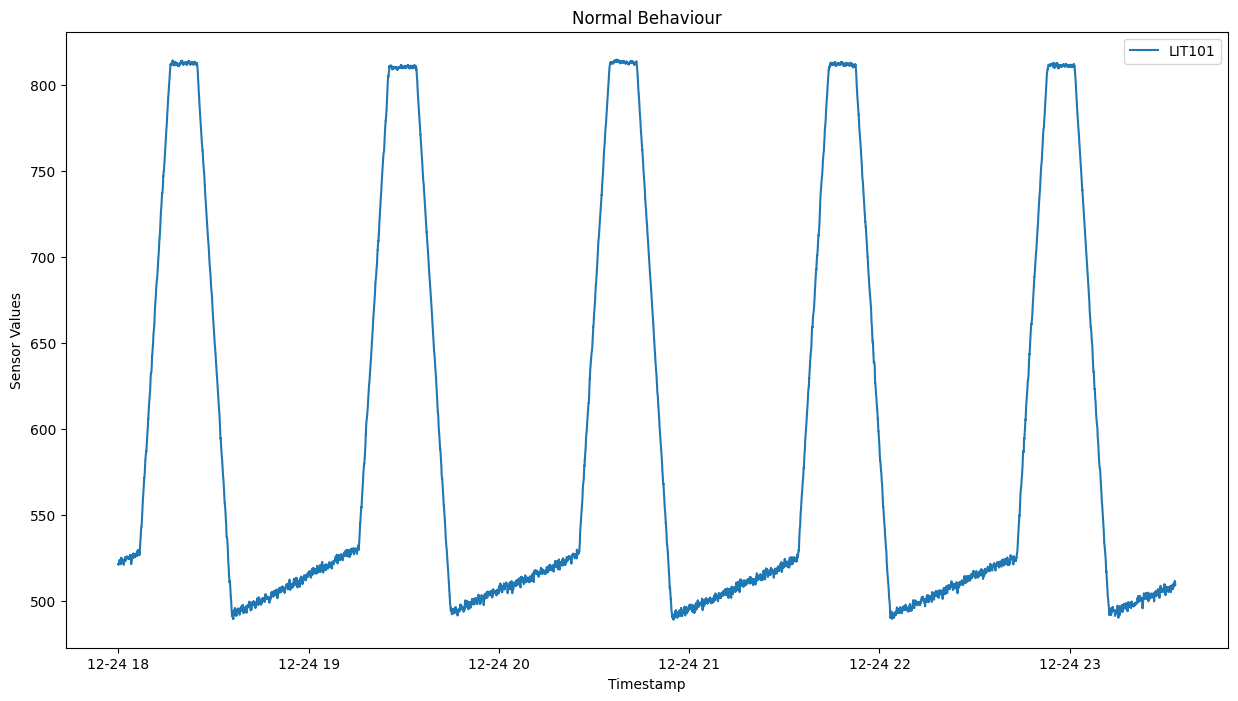

In [47]:
#Preprocessing step

# We choose LIT101 signal data and we visualize the whole data of the signal
print(train_data['LIT101'].shape)
visualize_sensor_data(train_data, sensors=['LIT101'], title= 'All LIT101 train data')

#We cut the first 20 000 points that we consider outliers
LIT101_train = train_data[20000:]['LIT101'] 

# We visualize the cut data of the sensor
visualize_sensor_data(train_data, window=(20000, len(LIT101_train)), sensors=['LIT101'], title='LIT101 train data without outliers')

# We visualize the data for the representative windows.
visualize_sensor_data(train_data, window=(180000, 200000), sensors=['LIT101'], title='Normal Behaviour')

In [48]:
# We try with window size = 10 and stride = 300
window_size = 10
stride = 300

# We create representative sliding windows for the train data
train_windows = np.lib.stride_tricks.sliding_window_view(LIT101_train, window_size, 0)[::stride]
representative_windows = np.lib.stride_tricks.sliding_window_view(LIT101_train[180000:200000], window_size, 0)[::stride]

We compare each window from the train data to each representative window and we add them to a list of distances only if they are not the same. Then, from all the distances we choose only the minimal one as this the distance to the closest representative window.

In [49]:
# Define a function to compute the minimum distance between a window and subsequent windows
def min_dtw_distance_windows(train_windows, representative_windows):
    min_distances = []
    
    for i, window in enumerate(train_windows):
        distances = []
        for j, representative_window in enumerate(representative_windows):
        # Calculate DTW distances with all subsequent windows
            if not np.array_equal(window, representative_window):
                distances.append(dynamic_time_warping(window, representative_window))
        # Store the minimum distance
        min_distances.append(min(distances))
    
    return np.array(min_distances)


We apply DTW on the train data and find the residuals ('train_distances') as well as the threshold, which is the mean value of the residuals plus 2 times the standard deviation of the residuals.

In [50]:
# Apply the function on train_windows
# Should take around 6s to run
train_distances = min_dtw_distance_windows(train_windows, representative_windows)

Threshold: 26.569589236637288
Number of Anomaly Windows: 129
(1590, 10)


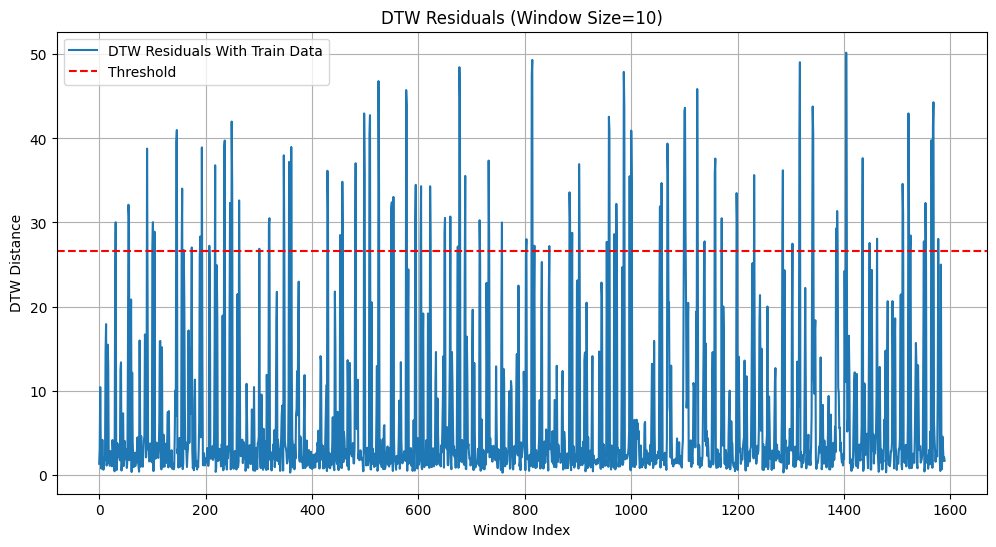

In [51]:
# We plot the results and the threshold.

# Determine threshold (e.g., mean + 2 * standard error)
threshold = np.mean(train_distances) + 2 * np.std(train_distances) 
anomalies = np.count_nonzero(train_distances > threshold)
print(f"Threshold: {threshold}")
print(f"Number of Anomaly Windows: {anomalies}")

print(train_windows.shape)
plt.figure(figsize=(12, 6))
plt.plot(train_distances, label="DTW Residuals With Train Data")
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel("Window Index")
plt.ylabel("DTW Distance")
plt.title(f"DTW Residuals (Window Size={window_size})")
plt.legend()
plt.grid()
plt.show()

We find that around 8% of the windows contain at least one anomaly point. So, there are at least 39 700 anomalies in the train data. Currently, we have many false anomalies, which can be improved by increasing the window size, but this will greatly increase the runtime. During our tests the anomalies were around 8% on average with different size and stride parameters.

We visualize the test data and apply the same steps for the test data. We use the representative windows from the train data as well as sliding windows from the test data and apply DTW on them. The result is 'test_distances' and these residuals are compared to the threshold we found from the train residuals. Finally, the anomalies are defined as every residual that is higher than the threshold. Here we find the windows indexes that have an anomaly in it and print them.

(449919,)


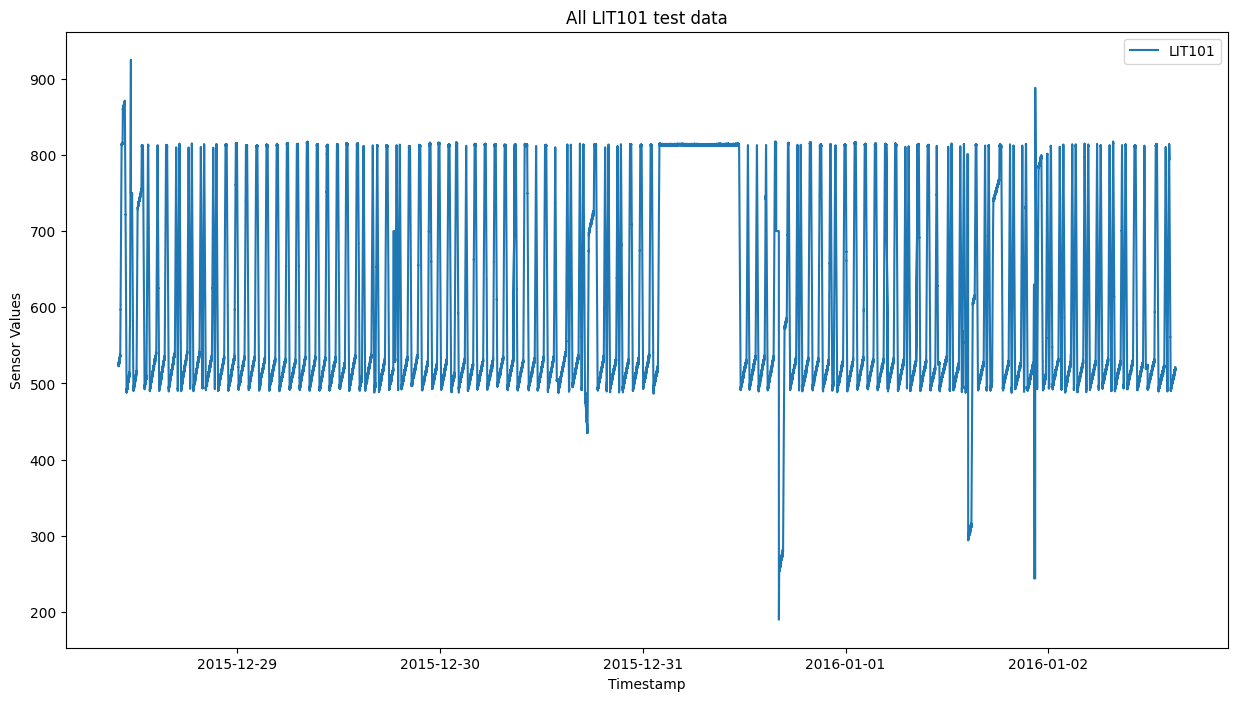

In [52]:
# We get the test data for the sensor
LIT101_test = test_data[:]['LIT101']

print(LIT101_test.shape)
# We visualize the test data
visualize_sensor_data(test_data, sensors=['LIT101'], title='All LIT101 test data')

In [53]:
# Should take around 6s to run
test_windows = np.lib.stride_tricks.sliding_window_view(LIT101_test, window_size, 0)[::stride]
test_distances = min_dtw_distance_windows(test_windows, representative_windows)

(1500, 10)
Threshold: 26.569589236637288
Number of Anomaly Windows: 162


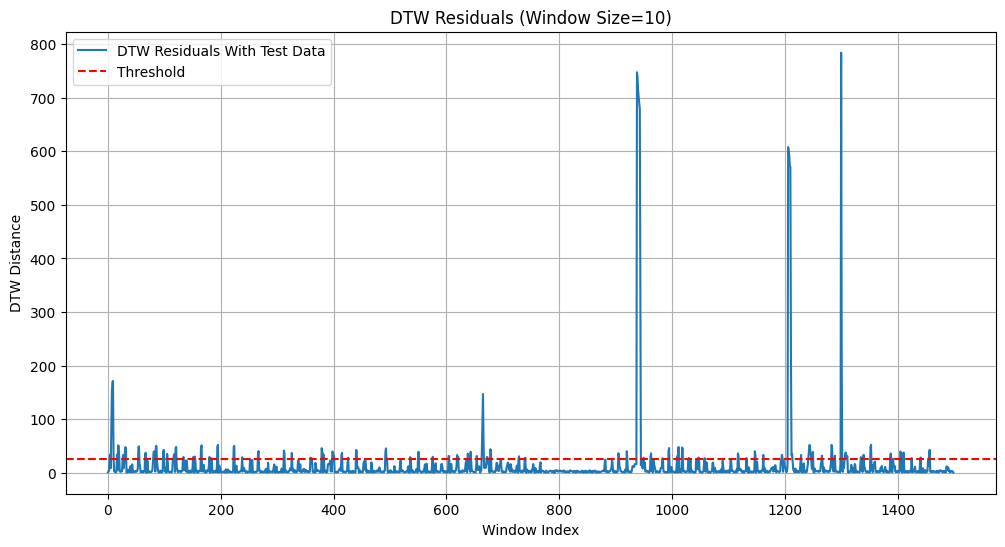

In [54]:
# We plot the residuals found from the test data and the representative windows. We find the number of anomalies and print it. 
print(test_windows.shape)

# Identify anomalies
anomalies = np.count_nonzero(test_distances > threshold)

# Print results
print(f"Threshold: {threshold}")
print(f"Number of Anomaly Windows: {anomalies}")

plt.figure(figsize=(12, 6))
plt.plot(test_distances, label="DTW Residuals With Test Data")
#Using a threshold with 2 times the standard deviation
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel("Window Index")
plt.ylabel("DTW Distance")
plt.title(f"DTW Residuals (Window Size={window_size})")
plt.legend()
plt.grid()
plt.show()

We find that around 11% of the windows over the test data contain at least one anomaly. This means that around 48 600 points are anomalous in the test set. In our opinion, this number is a bit more than in reality. Again, if we increase the window size we are going to get better results for detecting anomalies, but this will increase the runtime significantly. Moreover, as seen on the previous plot, the test data is quite different from the train data. By looking at the plot, we consider an increased number of anomalies as expected result from our algorithm. Finally, as we decided to concentrate on fast runtime, while still getting reasonable amount of anomalies, we consider this result fair enough. We conclude that using DTW we find point anomalies.

### PCA-based anomaly detection

We are going to apply PCA for just a couple number of components that we are going to choose based on their explained variance (more details are provided later). We will use them on the training data to find a new subspace and then reconstruct the original space back. Anomalous points are going to have difference in their value in original space compared to the reconstructed original space (these differences are the residuals). Based on these residuals we find a threshold that we are going to use to determine real non-anomalous data that we will use later (clean the data). Then, using the cleaned data per number of components we are going to apply PCA on the test data. Finally, We are going to evaluate the results for each of them and decide which performs best.

In [55]:
#Preprocessing step

#Taking from column 2 to 53 from train and test data (only signal data)
useful_train_data = train_data.iloc[:, 1:52]
print(useful_train_data.shape)

useful_test_data = test_data.iloc[:, 1:52]
print(useful_test_data.shape)

(496800, 51)
(449919, 51)


In [56]:
def principal_component_analysis(df, k):
    eigenvectors = np.zeros(shape=(df.shape[1], k))

    # START ANSWER
    
    #Standardizing the data 
    standardized_data = df - df.mean()
    covariance_matrix = covariance(standardized_data)
    #Compute eigenvectors and eigenvalues from the covariance matrix 
    eigenvalues, evectors = np.linalg.eig(covariance_matrix)

    #Sorting the indices in descending order based on their eigenvalue 
    sorted_indices = np.argsort(eigenvalues)[::-1]

    eigenvectors = evectors[:, sorted_indices[:k]]

    #Ensuring that each eigenvector has a unit length
    for i in range(k):
        eigenvectors[:, i] = eigenvectors[:, i] / np.linalg.norm(eigenvectors[:, i])
        
    #Compute the explained variance
    explained_var = eigenvalues.cumsum() / eigenvalues.sum()

    # END ANSWER

    return eigenvectors, explained_var
    

def apply_principal_component_analysis(df, eigenvectors):
    projected_data = np.zeros(shape=(df.shape[0], eigenvectors.shape[1]))

    # START ANSWER
    standardized_data = df - df.mean()

    projected_data = np.dot(standardized_data, eigenvectors)
    # END ANSWER

    return pd.DataFrame(projected_data)

def covariance(data):
    matrix = np.dot(data.T, data) / len(data) 
    return matrix

In [57]:
# Method used to print the number of anomalies, percentage of anomalies in the data and the decisions based on the residuals and the calculated threshold
def print_number_of_anomalies_and_decisions(residuals_data):    
    anomalies_dict = {}
    decisions_pca = {}
    percentages_dict = {}

    for n_components, residuals in residuals_data.items():
        threshold = np.mean(residuals) + 2 * np.std(residuals) 
        
        decision = (residuals > threshold).astype(int)
        decisions_pca[n_components] = decision

        anomalies_count = np.count_nonzero(residuals > threshold)
        anomalies_dict[n_components] = anomalies_count

        percentages_dict[n_components] = round(anomalies_count / len(residuals) * 100, 1)

    print("Anomalies Count per Component:")
    for n_components, anomalies in anomalies_dict.items():
        print(f"{n_components} components: {anomalies}")

    print("\nPercentage of Anomalies per Component:")
    for n_components, percentages in percentages_dict.items():
        print(f"{n_components} components: {percentages}%")

    print("\nDecisions for Each Component:")
    for n_components, decision_array in decisions_pca.items():
        print(f"{n_components} components: {decision_array}")

We are going to plot the explained variance for 2 to 10 number of components. Then, we are going to choose couple of values for number of components and apply PCA.


Explained Variance per Number of Components:
2 components: 0.8066504016004022
3 components: 0.9239874013918774
4 components: 0.976267769198435
5 components: 0.9883802462407215
6 components: 0.994367222355904
7 components: 0.998093836422263
8 components: 0.9989116458455415
9 components: 0.9995720355650854
10 components: 0.9998497559567981


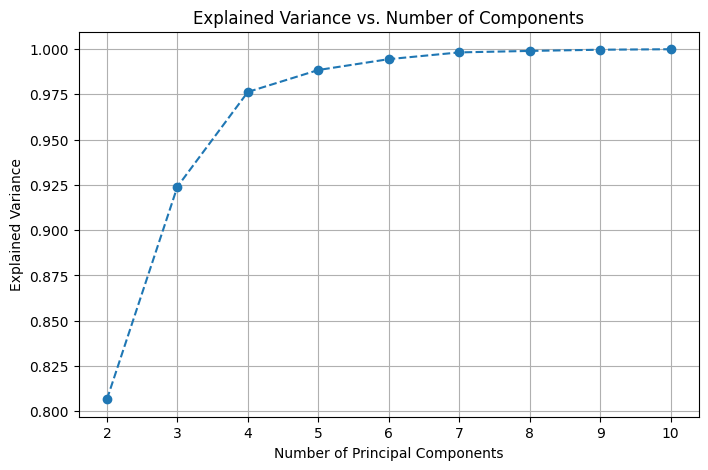

In [58]:
def plot_explained_variance(df):
    explained_var_list = []
    components = range(2, 11)

    # Calculate explained variance for 2 to 10 components
    print("\nExplained Variance per Number of Components:")
    for k in components:
        _, explained_var = principal_component_analysis(df, k)
        explained_var_list.append(explained_var[k-1])
        print(f'{k} components: {explained_var[k-1]}')

    # Plot the explained variance
    plt.figure(figsize=(8, 5))
    plt.plot(components, explained_var_list, marker='o', linestyle='--')
    plt.title('Explained Variance vs. Number of Components')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Explained Variance')
    plt.xticks(components)
    plt.grid()
    plt.show()

plot_explained_variance(useful_train_data)

Based on the plot and using the Elbow method, the best number of components is 4 as it maximizes the variance without overfitting the data (it is at the tip of the elbow like graph). We will consider also 2 components as it will represent underfitting results (expected) and 10 components as it will represent overfitting results (expected).

In [59]:
def visualize_PCA_residuals(n_components, residuals):
    plt.figure(figsize=(12, 6))

    #for n_components, residuals in residuals_dict:
    plt.plot(residuals, label=f'{n_components} Components')

    #Using a threshold with 2 times the standard deviation
    threshold = np.mean(residuals) + 2 * np.std(residuals)

    plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
    plt.xlabel("Data Point Index")
    plt.ylabel("Residual (Reconstruction Error)")
    plt.title("PCA Residuals for Different Number of Components")
    plt.legend()
    plt.grid()
    plt.show()


In [60]:
# Takes around 5s

#We find the residuals for 2,4 and 10 principal components after applying PCA. 

residuals_dict = {}
#Number of eigenvectors to test
n_components_list = [2, 4, 10]
all_components = list(range(2, 11))

for n_components in n_components_list:
    #PCA on training data
    eigenvectors, _ = principal_component_analysis(useful_train_data, n_components)

    #Transform both train and test data
    transformed_train_data = apply_principal_component_analysis(useful_train_data, eigenvectors)

    #Reconstruct the train data
    reconstructed_train_data = np.dot(transformed_train_data, eigenvectors.T)
    #Add back the mean
    mean_train_data = np.mean(useful_train_data, axis=0)
    mean_train_data = np.array(mean_train_data).reshape(1, -1)
    reconstructed_train_data += mean_train_data
    
    #Calculate residuals as the reconstruction error for each sample
    residuals = np.linalg.norm(useful_train_data - reconstructed_train_data, axis=1)
    residuals_dict[n_components] = residuals

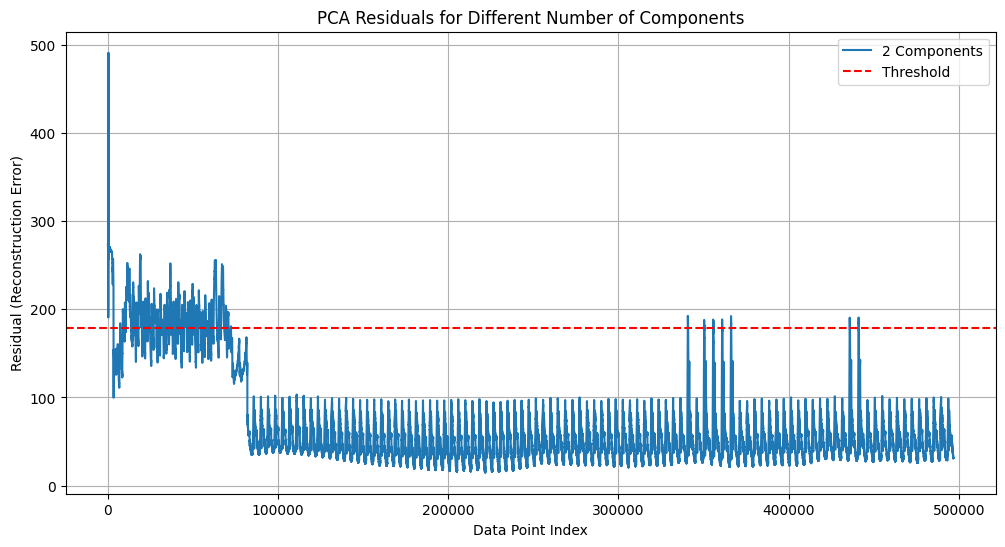

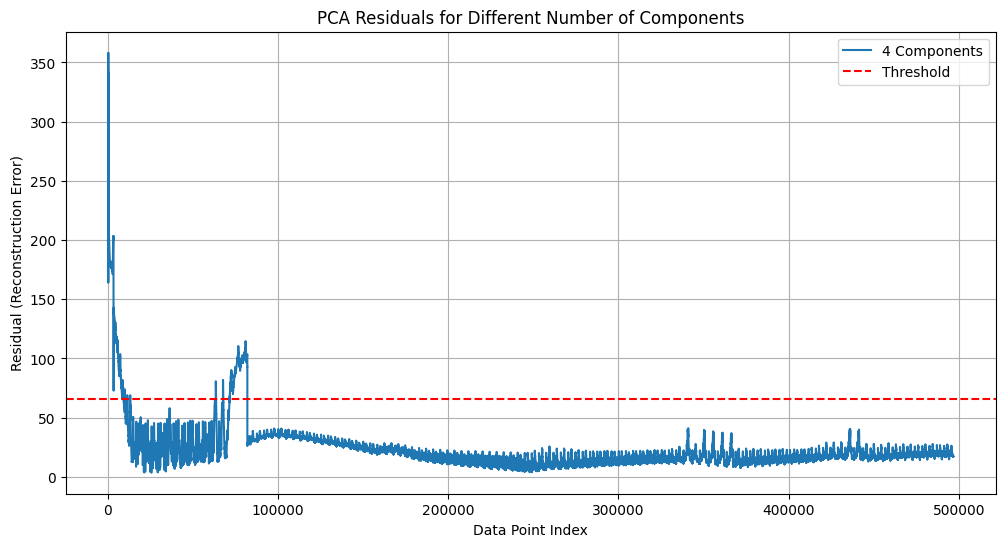

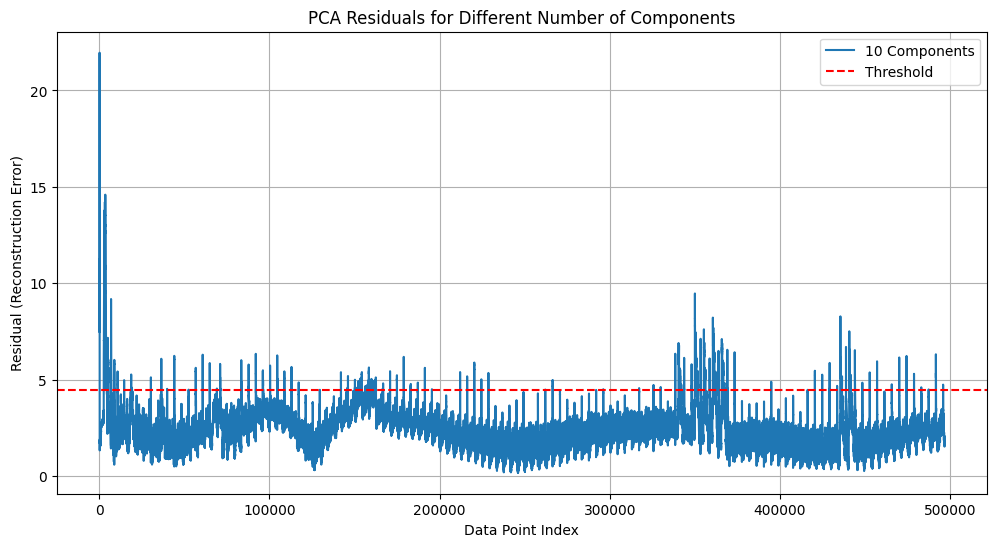

Anomalies Count per Component:
2 components: 37794
4 components: 20207
10 components: 15681

Percentage of Anomalies per Component:
2 components: 7.6%
4 components: 4.1%
10 components: 3.2%

Decisions for Each Component:
2 components: [1 1 1 ... 0 0 0]
4 components: [1 1 1 ... 0 0 0]
10 components: [1 1 1 ... 0 0 0]


In [61]:
#Visualize
for n_components, residuals in residuals_dict.items():
    visualize_PCA_residuals(n_components, residuals)

#Show number of anomalies
print_number_of_anomalies_and_decisions(residuals_dict)

Based on the result, we conclude that around 7.6% for 2 components, 4.1% for 4 components and 3.2% for 10 components of the points are considered anomalous by the PCA algorithm with these parameters. As mentioned before we expected the algorithm with 2 components to do worse (to underfit), while the algorithm with 10 components to do way better (to overfit) the data. Our expections were confirmed by the findings. We see that the number of anomalous points found by the PCA with 2 components is doubled to the other PCA implementations. This is mainly because the explained variance is significantly lower compared to the others. Also, the data is not well separated between 'Normal' data points and 'Attack' data points as they are probably grouped close together in the original space and then in the created subspace. Another thing is that there are large abnormalies in the beginning of the signals that is also visible in the residuals in that area. To improve our PCA analysis we will clean the train data from abnormalies.

To separate the points better, we are going to clean the train data from the anomalous points and use this new clean data to find eigenvectors. These eigenvectors are going to point in the direction of the 'Normal' data, so it will separate every anomalous point from the others quite well, since they will be in a sparse area of the original space, which will be then translated to the subspace.

In [62]:
#Cleaning the training data from anomalies. Returning the cleaned data 
def cleaning_data(data):    
    mean_residual = np.mean(data)
    std_residual = np.std(data)

    threshold_upper = mean_residual + 2 * std_residual

    # Identify clean data based on residual thresholds
    return np.array(useful_train_data[
        (data <= threshold_upper)
    ])

In [63]:
# Getting a clean data per number of components and their threshold for finding anomalities
clean_data_2_comp = cleaning_data(residuals_dict[2])
clean_data_4_comp = cleaning_data(residuals_dict[4])
clean_data_10_comp = cleaning_data(residuals_dict[10])

Finally, we use the cleaned data to find the corresponding eigenvectors and apply PCA to the test data. The residuals are plotted with the corresponding thresholds. (It should run in around 6s).

In [64]:
#Apply PCA with eigenvectors computed from the new clean training data
residuals_dict_clean_data = {}
clean_data_n_comp = [clean_data_2_comp, clean_data_4_comp, clean_data_10_comp]

for n_components, clean_data in zip(n_components_list, clean_data_n_comp):
    
    eigenvectors, _ = principal_component_analysis(clean_data, n_components)

    transformed_test_data = apply_principal_component_analysis(useful_test_data, eigenvectors)

    #Reconstruct the test data
    reconstructed_test_data = np.dot(transformed_test_data, eigenvectors.T)
    #Add back the mean
    mean_test_data = np.mean(useful_test_data, axis=0)
    mean_test_data = np.array(mean_test_data).reshape(1, -1)
    reconstructed_test_data += mean_test_data

    #Calculate residuals as the reconstruction error for each sample
    residuals = np.linalg.norm(useful_test_data - reconstructed_test_data, axis=1)
    residuals_dict_clean_data[n_components] = residuals

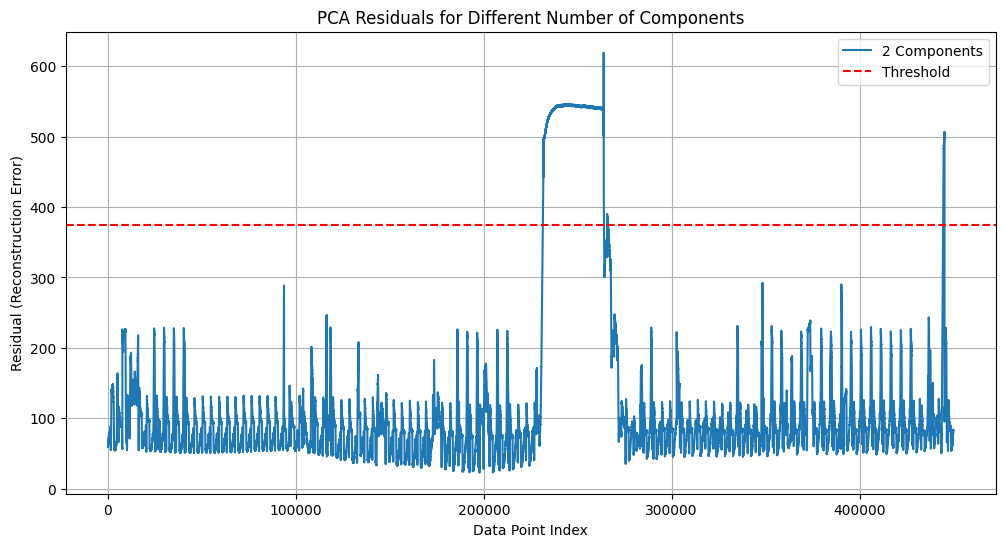

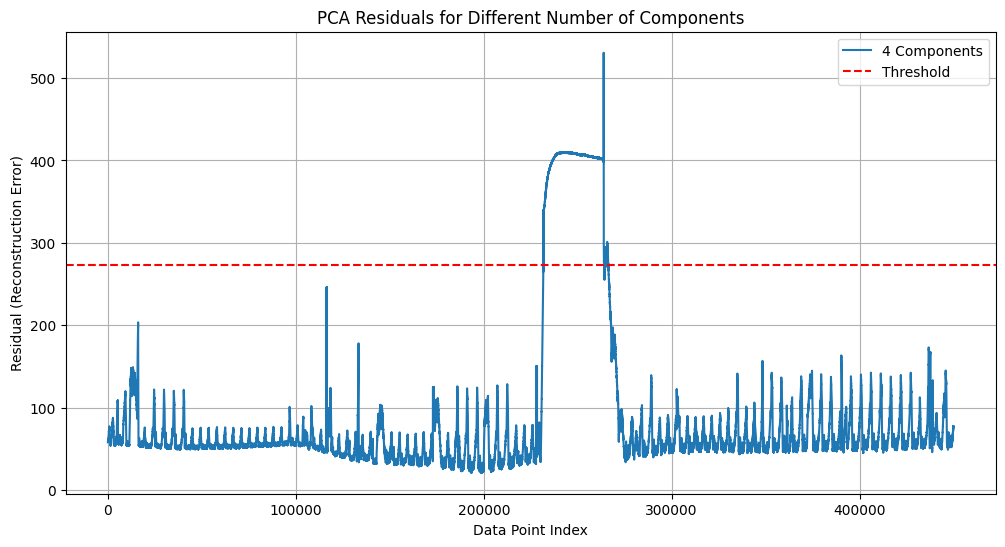

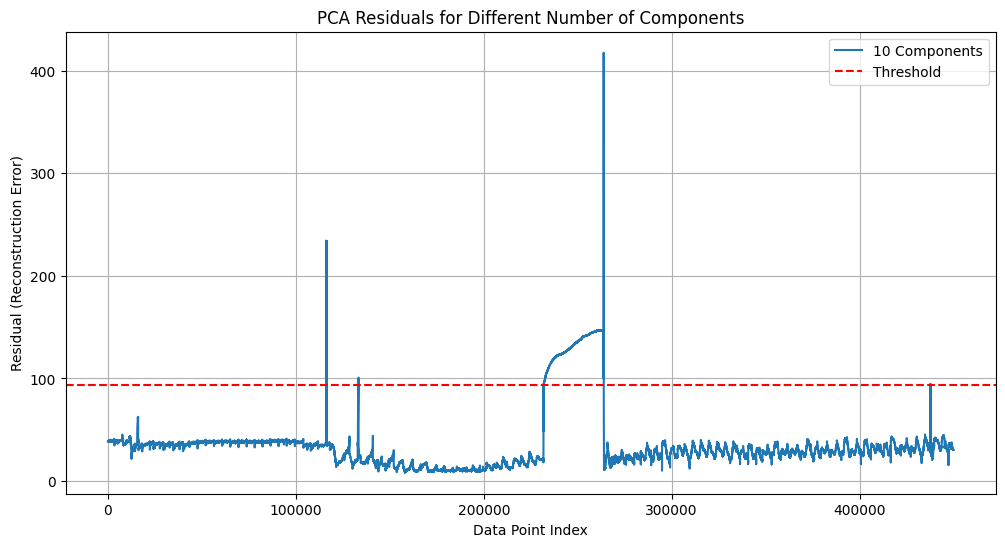

Anomalies Count per Component:
2 components: 33579
4 components: 33899
10 components: 32540

Percentage of Anomalies per Component:
2 components: 7.5%
4 components: 7.5%
10 components: 7.2%

Decisions for Each Component:
2 components: [0 0 0 ... 0 0 0]
4 components: [0 0 0 ... 0 0 0]
10 components: [0 0 0 ... 0 0 0]

Explained Variance per Number of Components:
2 components: 0.8675436697912007
3 components: 0.952293701798912
4 components: 0.9749663101107282
5 components: 0.9950343461017048
6 components: 0.9964462222234307
7 components: 0.9975294147099218
8 components: 0.9984405585374058
9 components: 0.9990746961171538
10 components: 0.9996015258596852


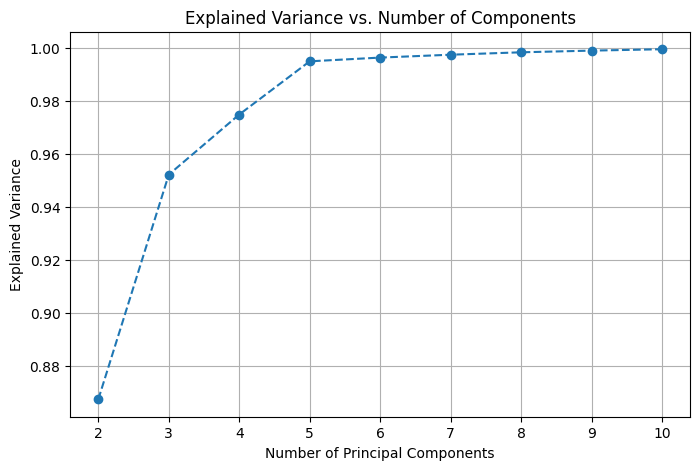

In [65]:
#Visualize
for n_components, residuals in residuals_dict_clean_data.items():
    visualize_PCA_residuals(n_components, residuals)

#Print the number of anomalies found
print_number_of_anomalies_and_decisions(residuals_dict_clean_data)

#Plot the explained variance in the test data
plot_explained_variance(useful_test_data)

We conclude that with 4 components we find anomalies with minimum number of false alarms without overfitting. Based on the explained variance plot for the test data, we can see that either 3, 4 or 5 components work best in terms of giving enough anomalies without overfitting the data. The explained variance changes by 2% in this area. So, a PCA analysis with 4 components is still a decent choice even for the test data. There are no changes as to PCA analysis with 2 and 10 components. The plot with explained variance confirms again our initial predictions that they are going to underfit and overfit the data, respectfully. Finally, let analyse the results in terms of percentage of anomalies. We get 7.5%, 7.5%, 7.2% for 2, 4 and 10 components. The results are pretty close to each other, which we believe indicates that using the clean data to find the eigenvectors really makes it way easier to distinguish the anomalies in the test data even with lower number of principal components. We conclude that using PCA analysis we find point anomalies in the data.